# 04 - Behavioural segmentation (K-Means)
**Question:** beyond hand-written rules, what natural groups exist in customer behaviour?

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from src.config import *
from src import eda, evaluation as ev
from src.feature_engineering import *
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

In [2]:
customers = pd.read_csv(DATA_PROC / "customers_clean.csv", parse_dates=["customer_registration_date"])
tx = pd.read_csv(DATA_PROC / "transactions_clean.csv.gz", parse_dates=["date"])
orders = build_orders(tx); lines, returns = tx[~tx.is_return], tx[tx.is_return]
M = json.load(open(DATA_PROC / "metrics.json")); H = M["H"]
meta = json.load(open(DATA_PROC / "run_metadata.json"))
START, END = pd.Timestamp(M["data_start"]), pd.Timestamp(M["data_end"])
FEATURES_USED = meta["features_used"]
train_c = [pd.Timestamp(c) for c in M["train_cutoffs"]]; val_c = pd.Timestamp(M["val_cutoff"]); test_c = pd.Timestamp(M["test_cutoff"])
display(Markdown(f"> **Dataset: {meta['name']}** ({'SIMULATED' if meta['kind'] == 'synthetic' else 'real'}) | {M['data_start']} -> {M['data_end']} | churn window **{H} days** ({M['churn_window_source']}). "
                 "All numbers in the commentary below are computed from this dataset when the notebook runs."))

> **Dataset: online_retail_ii** (real) | 2009-12-01 -> 2011-12-09 | churn window **180 days** (P95 of purchase gaps = 221 days, rounded up to a multiple of 15). All numbers in the commentary below are computed from this dataset when the notebook runs.

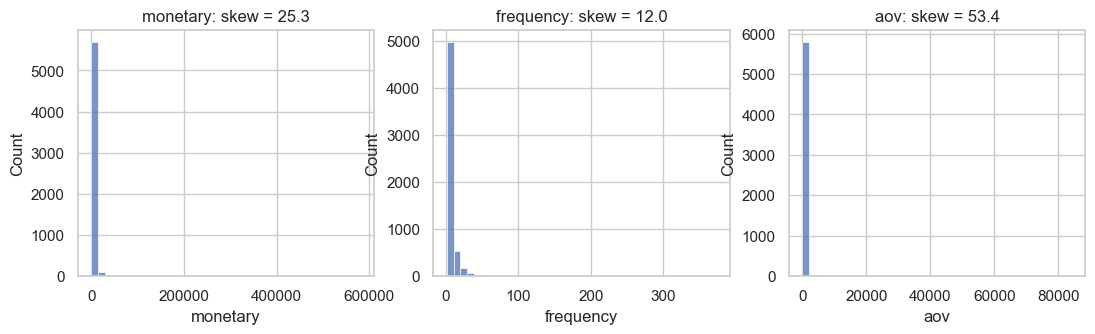

clustering features available in this dataset: ['recency_days', 'frequency', 'monetary', 'aov', 'purchase_frequency_30d']
after log1p -> winsorise -> standardise: skew = {'recency_days': -0.52, 'frequency': 0.82, 'monetary': 0.22, 'aov': 0.02, 'purchase_frequency_30d': 1.56}


In [3]:
from src.segmentation import *
f = compute_features(orders, lines, returns, customers, END)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, c in zip(ax, ["monetary", "frequency", "aov"]):
    sns.histplot(f[c], ax=a, bins=40); a.set_title(f"{c}: skew = {f[c].skew():.1f}")
plt.show()
cl_feats = [c for c in CLUSTER_FEATURES if f[c].notna().any() and f[c].nunique() > 1]
print("clustering features available in this dataset:", cl_feats)
assert len(f) >= MIN_CUSTOMERS_FOR_CLUSTERING, "too few customers for clustering"
X, cols = prepare_matrix(f, cl_feats)
print("after log1p -> winsorise -> standardise: skew =", pd.DataFrame(X, columns=cols).skew().round(2).to_dict())

**Why scale?** K-Means groups points by Euclidean distance. Without scaling, `monetary` (hundreds/thousands) would dominate `n_unique_categories` (1-8) purely because of units. Log-transform + winsorising tame the long right tail so a few huge customers do not drag the centroids.

,k,inertia,silhouette
0,2,17496.147,0.362
1,3,14001.133,0.267
2,4,11747.153,0.279
3,5,10140.494,0.266
4,6,9008.827,0.270
5,7,8117.626,0.260
6,8,7527.615,0.258


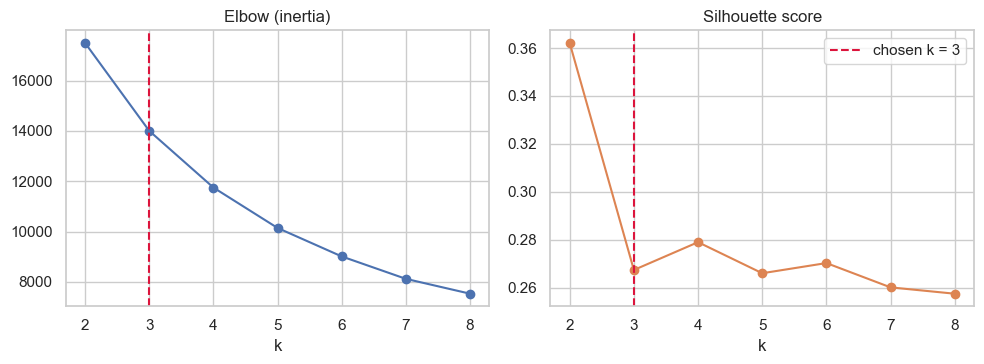

chosen k = 3; stability across seeds (ARI) = 1.000


In [4]:
ev_k = evaluate_k(X); k = choose_k(ev_k)
display(ev_k.round(3)); eda.fig_k_selection(ev_k, k); plt.show()
print(f"chosen k = {k}; stability across seeds (ARI) = {stability(X, k):.3f}")

**Why not simply the highest silhouette?** k = 2 always scores best (it just splits active from inactive), which is useless for marketing. We restrict to an actionable range (3-6) and take the smallest k within 10% of the best silhouette in that range. The silhouette value printed above tells how separated the groups are: below ~0.25 means weak structure (behaviour is closer to a continuum than to distinct groups), 0.25-0.5 means real but overlapping groups, above 0.5 clearly separated groups.

,recency_days,frequency,monetary,aov,purchase_frequency_30d,customers,revenue_share,lapsed_share
"C0: Dormant, mid-value",354.07,1.73,284.93,183.41,0.19,2077,0.03,0.75
"C1: Cooling, mid-value",160.98,4.07,1653.91,483.88,0.32,2485,0.24,0.33
"C2: Active, high-value",25.89,17.74,9586.65,516.40,1.13,1290,0.72,0.02


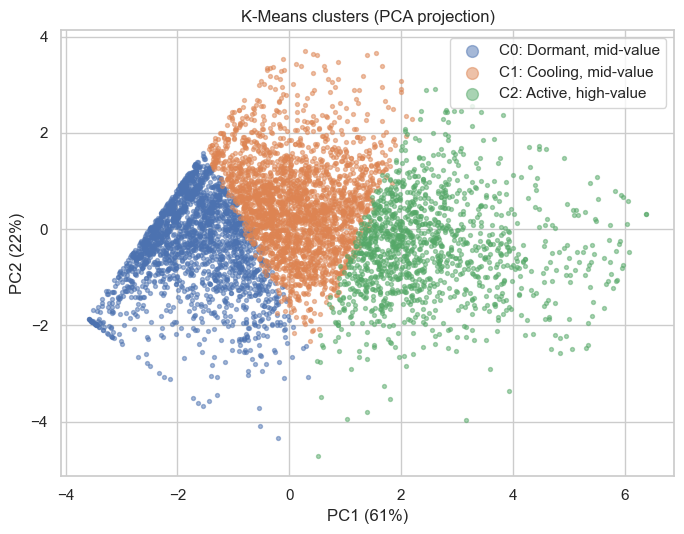

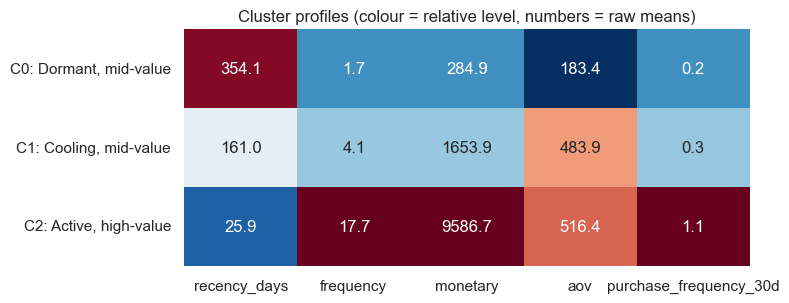

In [5]:
km = fit_kmeans(X, k); f["cluster"] = km.labels_
prof = f.groupby("cluster")[cl_feats].mean()
names = name_clusters(prof, f)
prof_out = prof.copy(); prof_out["customers"] = f.groupby("cluster").size(); prof_out["revenue_share"] = f.groupby("cluster").monetary.sum() / f.monetary.sum()
prof_out["lapsed_share"] = f.groupby("cluster").recency_days.apply(lambda s: (s > H).mean()); prof_out.index = [names[i] for i in prof_out.index]
display(prof_out.round(2))
eda.fig_clusters_pca(X, km.labels_, names); plt.show()
eda.fig_cluster_heatmap(prof, names); plt.show()

In [6]:
cl = prof_out
hi = cl.revenue_share.idxmax(); lo = cl.lapsed_share.idxmax()
sil = float(ev_k.set_index("k").silhouette[k])
display(Markdown(f"""**So what? (business reading of the clusters, computed from this dataset)**
* Silhouette for k = {k}: **{sil:.2f}**.
* **{hi}** generates the largest revenue share (**{cl.loc[hi,'revenue_share']:.0%}**) with {cl.loc[hi,'customers']:,.0f} customers ({cl.loc[hi,'customers']/cl.customers.sum():.0%}); on average {cl.loc[hi,'frequency']:.1f} orders and {cl.loc[hi,'recency_days']:.0f} days since the last purchase. Check these two numbers before calling it 'engaged'.
* **{lo}** has the highest lapsed share ({cl.loc[lo,'lapsed_share']:.0%}) and {cl.loc[lo,'revenue_share']:.0%} of revenue.
* Names such as 'Active, high-value' are generated automatically from each cluster's recency / frequency / spend relative to all customers; read the table, not just the label.

Clusters complement RFM: RFM is a transparent rulebook; clusters are learned from the behaviours listed above and need no hand-set thresholds."""))

**So what? (business reading of the clusters, computed from this dataset)**
* Silhouette for k = 3: **0.27**.
* **C2: Active, high-value** generates the largest revenue share (**72%**) with 1,290 customers (22%); on average 17.7 orders and 26 days since the last purchase. Check these two numbers before calling it 'engaged'.
* **C0: Dormant, mid-value** has the highest lapsed share (75%) and 3% of revenue.
* Names such as 'Active, high-value' are generated automatically from each cluster's recency / frequency / spend relative to all customers; read the table, not just the label.

Clusters complement RFM: RFM is a transparent rulebook; clusters are learned from the behaviours listed above and need no hand-set thresholds.